<a href="https://colab.research.google.com/github/sayu0303/CONTROLE-2025/blob/main/CONTROLE_030226_P8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalar e importas as bibliotecas necessárias

In [136]:
! pip install -qq control

In [137]:
import numpy as np
import control as ct
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Identificar o modelo do processo
Considere um problema em que a corrente de um processo deve ser aquecida usando um trocador de calor de casco e tubo. A temperatura de saída é controlada ajustando a válvula de vapor.

Durante um teste experimental em malha aberta, a pressão do vapor Ps foi alterada repentinamente de 18 a 20 psi e foram obtidos os dados de temperatura na tabela de dados experimentais.

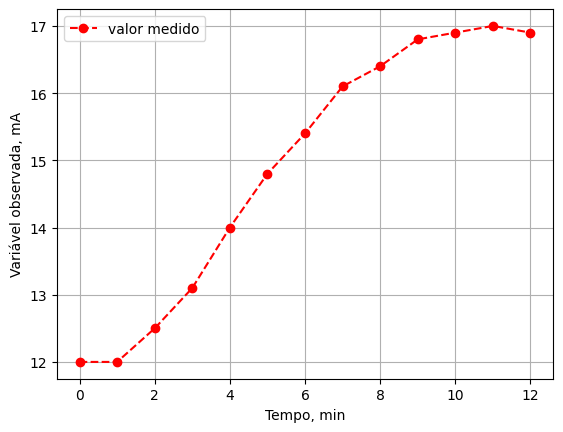

In [138]:
# Dados experimentais
t = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
T_2m = np.array([12, 12, 12.5, 13.1, 14, 14.8, 15.4, 16.1, 16.4, 16.8, 16.9, 17, 16.9])

plt.plot(t,T_2m, '--or', label = 'valor medido')
plt.xlabel('Tempo, min')
plt.ylabel('Variável observada, mA')
plt.legend()
plt.grid()

# Identificação do modelo do processo

In [139]:
# Dados do teste experimental
Delta_Ps = 20-18
Delta_T2m = 17-T_2m[0]

# Ganho estacionário
Kp =  Delta_T2m/Delta_Ps
print(f'Ganho estacionário do processo: Kp = {Kp:1.4f}')

# Tempo-morto e constante de tempo ()
theta = 2.0
taup = 5.5-theta
print(r'Tempo-morto: theta = %1.2f; Constante de tempo: taup = %1.2f' %(theta, taup))

Ganho estacionário do processo: Kp = 2.5000
Tempo-morto: theta = 2.00; Constante de tempo: taup = 3.50


Dessa forma,

$$G_p(s) = \frac{2.5e^{-2s}}{3.5s+1}$$

# Validar o modelo

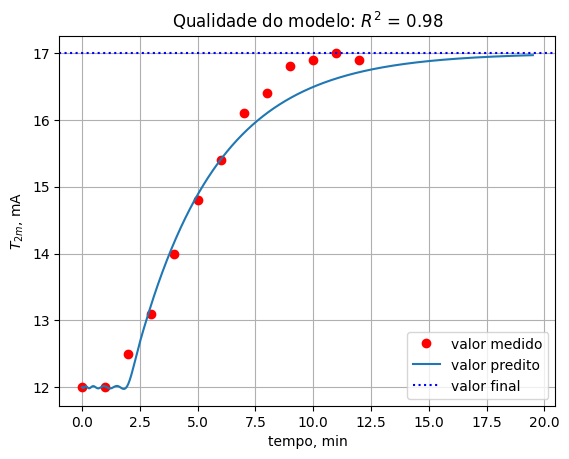

In [140]:
# Implementar o modelo
s = ct.tf('s')
Gtd = ct.tf(*ct.pade(theta,10))
Gp = Kp/(taup*s+1)*Gtd

# Testar o modelo na mesma condição dos dados
tval0, yval0 = ct.step_response(Gp,T=t)
Tval0 = Delta_Ps*yval0 + T_2m[0]

tval, yval = ct.step_response(Gp,T=5*taup+theta)

plt.plot(t, T_2m, 'or', label = 'valor medido')
plt.plot(tval, Delta_Ps*yval + T_2m[0] , label='valor predito')
plt.axhline(y=17, linestyle = ':', color = 'blue', label = 'valor final')

plt.xlabel('tempo, min')
plt.ylabel(r'$T_{2m}$, mA')
plt.title(r'Qualidade do modelo: $R^2$ = %1.2f' %r2_score(T_2m, Tval0) )
plt.legend()
plt.grid()

# Ajuste dos parâmetros do controlador
$\color{red}{\text{Vamos fazer juntos!}}$

IMC: Kc =  0.35; tauI = 3.5
13 states have been removed from the model


Text(0, 0.5, '$T_{2m}$,mA')

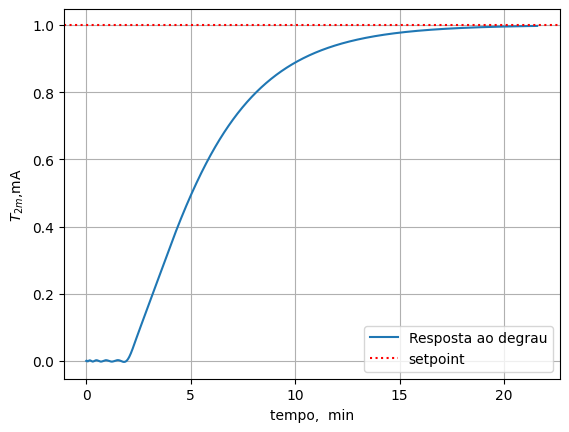

In [141]:
#IMC

tauc = theta

Kc = taup / (Kp*(tauc + theta))

tauI = taup

print(f'IMC: Kc =  {Kc}; tauI = {tauI}')

#CRIAR A GC USANDO controlador pi

Gc = Kc*(1+1/(tauI*s))

#Teste servo em malha fechada

Gv = 0.9
G_IP = 0.75

#MALHA FECHADA
G_servo = ct.minreal((Gc*G_IP*Gv*Gp)/(1+Gc*G_IP*Gv*Gp))


#Simulação da malha fechada

tsim, ysim =  ct.step_response(G_servo)

#Visualização

plt.plot(tsim,ysim, label = 'Resposta ao degrau')
plt.axhline(y=1, linestyle = ':', color = 'red', label = 'setpoint')
plt.legend()
plt.grid()
plt.xlabel('tempo,  min')
plt.ylabel(r'$T_{2m}$,mA')

ITAE: Kc = 0.5936101643412778; tauI = 3.549296450075397 
12 states have been removed from the model


Text(0, 0.5, '$T_{2m}$,mA')

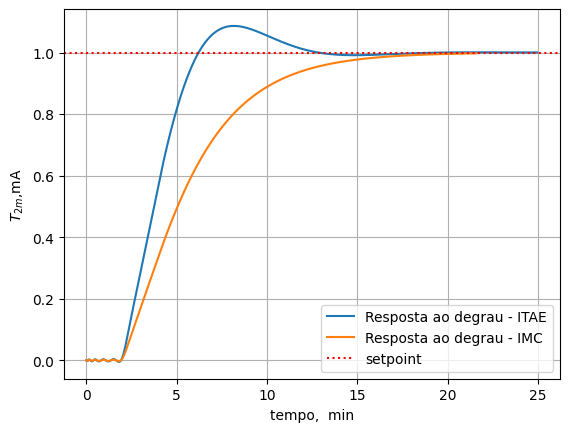

In [142]:
#ITAE

A = 0.859
B = -0.977
C = 0.674
D = -0.680

tauI_ITAE = taup/(C*((theta/taup)**D))


Kc_ITAE = (A/Kp)*((theta/taup)**B)

print(f'ITAE: Kc = {Kc_ITAE}; tauI = {tauI_ITAE} ')

#CRIAR A GC USANDO controlador pi

Gc_ITAE = Kc_ITAE*(1+1/(tauI_ITAE*s))

#Teste servo em malha fechada

Gv = 0.9
G_IP = 0.75

#MALHA FECHADA
G_servo = ct.minreal((Gc_ITAE*G_IP*Gv*Gp)/(1+Gc_ITAE*G_IP*Gv*Gp))


#Simulação da malha fechada

tsim2, ysim2 =  ct.step_response(G_servo)

#Visualização

plt.plot(tsim2,ysim2, label = 'Resposta ao degrau - ITAE')
plt.plot(tsim,ysim, label = 'Resposta ao degrau - IMC')
plt.axhline(y=1, linestyle = ':', color = 'red', label = 'setpoint')
plt.legend()
plt.grid()
plt.xlabel('tempo,  min')
plt.ylabel(r'$T_{2m}$,mA')
